In [7]:
import os
import pickle
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix


In [8]:
# this is with retraining both first and second stage model, but with deleting output files from previous runs

results_dir = '/Users/eagle/Documents/eagle-classification/ChannelViT/results_test20'  
pickle_files = [f for f in os.listdir(results_dir) if f.endswith('.pkl') or f.endswith('.pickle')]

pred_labels_all = []
true_labels_all = []
probs = []
for fname in pickle_files:
    file_path = os.path.join(results_dir, fname)
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
        print(data.keys())
        pred_labels_all.extend(data['pred_labels'])
        true_labels_all.extend(data['true_labels'])
        probs.extend(data['probabilities'])

dict_keys(['pred_labels', 'true_labels', 'probabilities'])
dict_keys(['pred_labels', 'true_labels', 'probabilities'])
dict_keys(['pred_labels', 'true_labels', 'probabilities'])
dict_keys(['pred_labels', 'true_labels', 'probabilities'])
dict_keys(['pred_labels', 'true_labels', 'probabilities'])
dict_keys(['pred_labels', 'true_labels', 'probabilities'])
dict_keys(['pred_labels', 'true_labels', 'probabilities'])


In [9]:
pred_labels_all = np.array(pred_labels_all)
true_labels_all = np.array(true_labels_all)
probs = np.array(probs)
print("Predicted labels:", len(pred_labels_all))


Predicted labels: 90


In [10]:

n_cols = pred_labels_all.shape[1]
for col in range(n_cols):
    col_preds = pred_labels_all[:, col]
    col_trues = true_labels_all[:, col]
    print(f"  Column {col}:")
    print("    Accuracy:", accuracy_score(col_trues, col_preds))
    print("    Precision:", precision_score(col_trues, col_preds, average='weighted', zero_division=0))
    print("    Recall:", recall_score(col_trues, col_preds, average='weighted', zero_division=0))
    print("    F1 Score:", f1_score(col_trues, col_preds, average='weighted', zero_division=0))
    print(classification_report(col_trues, col_preds, zero_division=0))
    
    print("    Confusion Matrix:")
    print(confusion_matrix(col_trues, col_preds))
    print("\n")

  Column 0:
    Accuracy: 0.8222222222222222
    Precision: 0.792006119716963
    Recall: 0.8222222222222222
    F1 Score: 0.7908831908831909
              precision    recall  f1-score   support

         0.0       0.84      0.96      0.90        73
         1.0       0.57      0.24      0.33        17

    accuracy                           0.82        90
   macro avg       0.71      0.60      0.62        90
weighted avg       0.79      0.82      0.79        90

    Confusion Matrix:
[[70  3]
 [13  4]]


  Column 1:
    Accuracy: 0.7888888888888889
    Precision: 0.6382022471910112
    Recall: 0.7888888888888889
    F1 Score: 0.7055900621118012
              precision    recall  f1-score   support

         0.0       0.80      0.99      0.88        72
         1.0       0.00      0.00      0.00        18

    accuracy                           0.79        90
   macro avg       0.40      0.49      0.44        90
weighted avg       0.64      0.79      0.71        90

    Confusion Matr

/Users/eagle/Documents/eagle-classification/venv_eagle_class/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


/Users/eagle/Documents/eagle-classification/venv_eagle_class/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


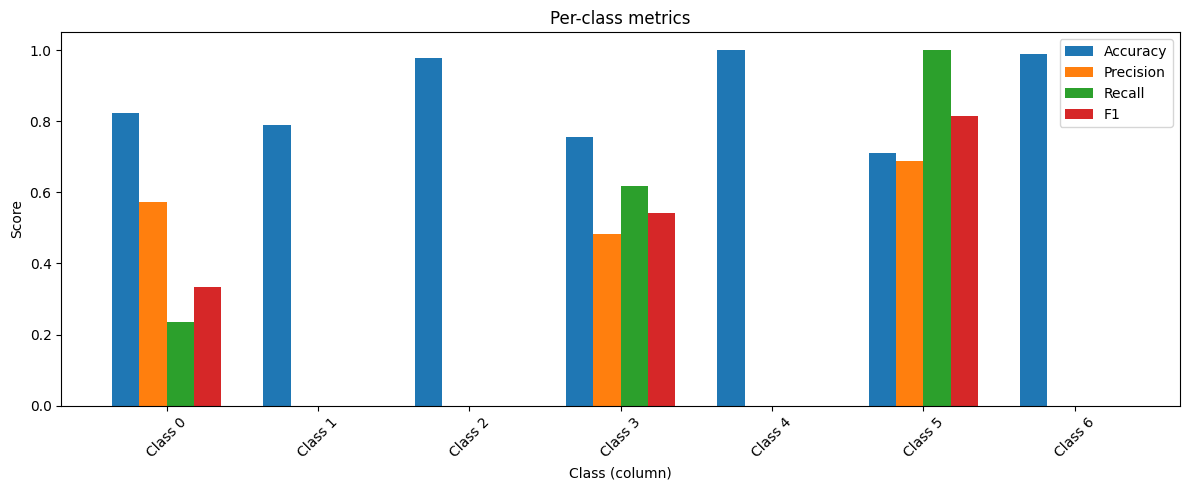

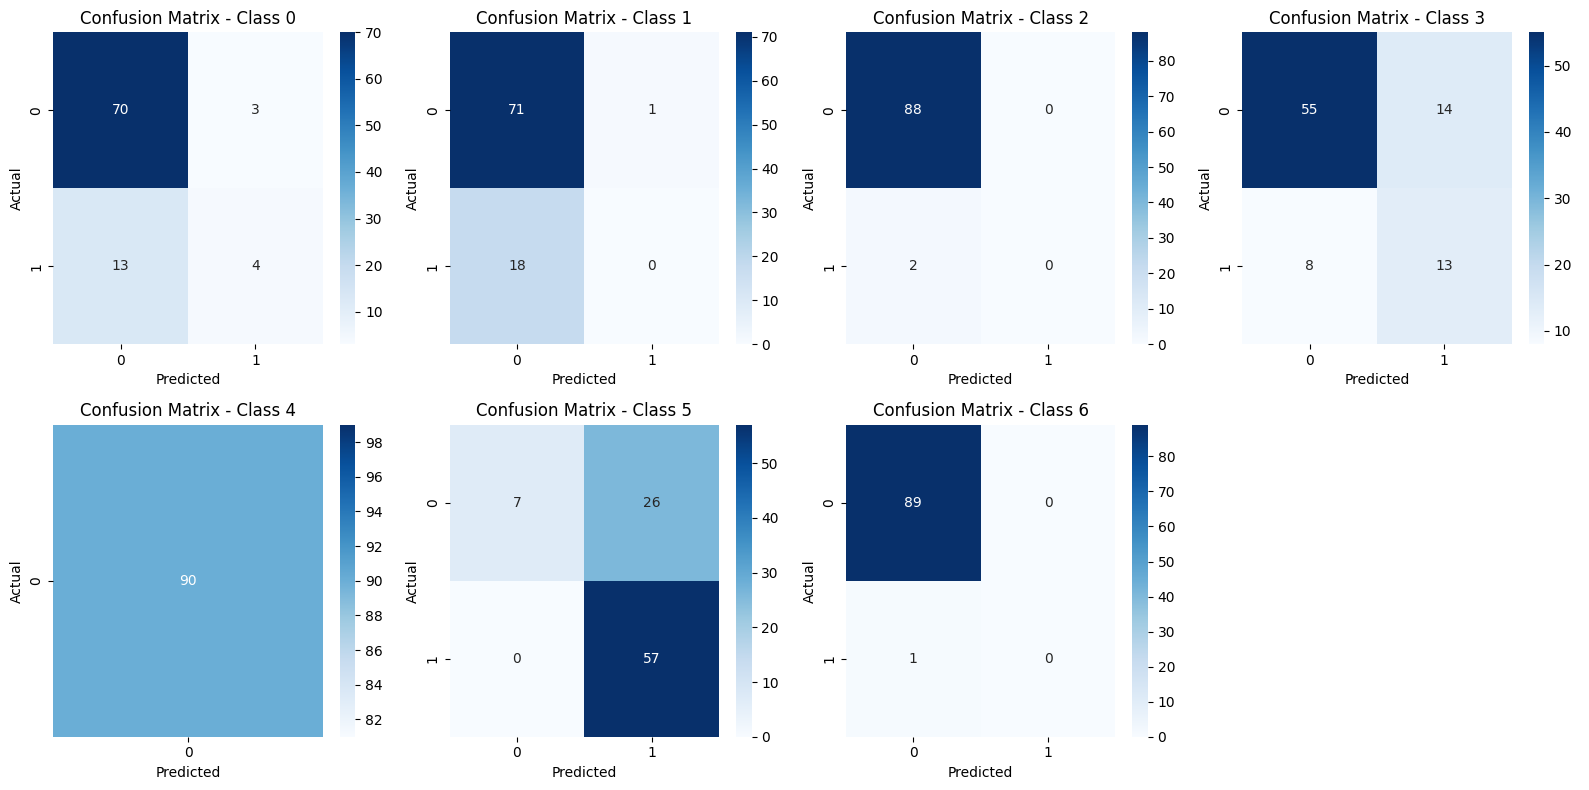

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# pred_labels_all and true_labels_all are expected to be numpy arrays from previous cells
n_cols = pred_labels_all.shape[1]

# Compute metrics per column
accs = []
precs = []
recs = []
f1s = []
conf_matrices = []

for col in range(n_cols):
    y_pred = pred_labels_all[:, col]
    y_true = true_labels_all[:, col]
    accs.append(accuracy_score(y_true, y_pred))
    precs.append(precision_score(y_true, y_pred, zero_division=0))
    recs.append(recall_score(y_true, y_pred, zero_division=0))
    f1s.append(f1_score(y_true, y_pred, zero_division=0))
    conf_matrices.append(confusion_matrix(y_true, y_pred))

cols = np.arange(n_cols)

# Plot bar chart of metrics
plt.figure(figsize=(12, 5))
width = 0.18
plt.bar(cols - 1.5*width, accs, width, label='Accuracy')
plt.bar(cols - 0.5*width, precs, width, label='Precision')
plt.bar(cols + 0.5*width, recs, width, label='Recall')
plt.bar(cols + 1.5*width, f1s, width, label='F1')
plt.xticks(cols, [f'Class {i}' for i in cols], rotation=45)
plt.ylim(0, 1.05)
plt.xlabel('Class (column)')
plt.ylabel('Score')
plt.title('Per-class metrics')
plt.legend()
plt.tight_layout()
plt.show()

# Plot confusion matrices (2x2) in a grid
n_rows = int(np.ceil(n_cols / 4))
fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i in range(len(axes)):
    if i < n_cols:
        cm = conf_matrices[i]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
        axes[i].set_title(f'Confusion Matrix - Class {i}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
    else:
        axes[i].axis('off')

plt.tight_layout()
plt.show()

/Users/eagle/Documents/eagle-classification/venv_eagle_class/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


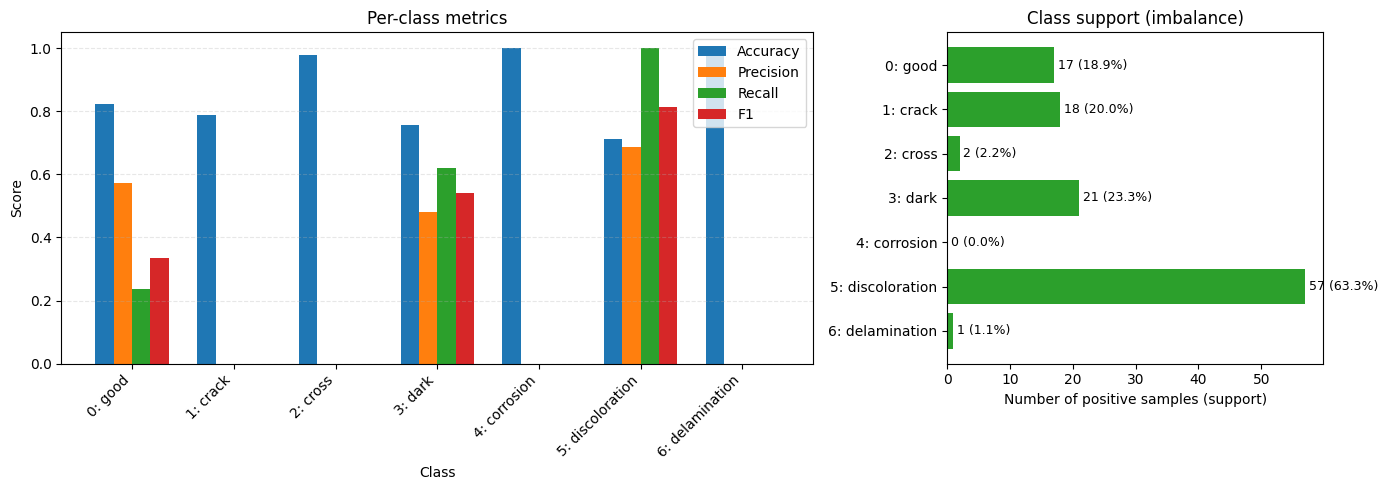

In [12]:
# Plot per-class metrics together with class support (imbalance)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Ensure arrays exist
pred = np.array(pred_labels_all)
true = np.array(true_labels_all)

# Class names
class_names = [
    'good', 'crack', 'cross', 'dark', 'corrosion', 'discoloration', 'delamination'
]

n_cols = pred.shape[1]

# Compute metrics per column
accs, precs, recs, f1s, conf_matrices = [], [], [], [], []
for col in range(n_cols):
    y_pred = pred[:, col]
    y_true = true[:, col]
    accs.append(accuracy_score(y_true, y_pred))
    precs.append(precision_score(y_true, y_pred, zero_division=0))
    recs.append(recall_score(y_true, y_pred, zero_division=0))
    f1s.append(f1_score(y_true, y_pred, zero_division=0))
    conf_matrices.append(confusion_matrix(y_true, y_pred))

# Class support (number of positive samples per class)
support = np.sum(true.astype(int), axis=0)
total_samples = true.shape[0]
support_pct = support / total_samples * 100.0

cols = np.arange(n_cols)

# Create combined figure: left metrics, right support
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios':[2,1]})

# Metrics bar chart
width = 0.18
ax1.bar(cols - 1.5*width, accs, width, label='Accuracy')
ax1.bar(cols - 0.5*width, precs, width, label='Precision')
ax1.bar(cols + 0.5*width, recs, width, label='Recall')
ax1.bar(cols + 1.5*width, f1s, width, label='F1')
ax1.set_xticks(cols)
ax1.set_xticklabels([f'{i}: {name}' for i, name in enumerate(class_names)], rotation=45, ha='right')
ax1.set_ylim(0, 1.05)
ax1.set_xlabel('Class')
ax1.set_ylabel('Score')
ax1.set_title('Per-class metrics')
ax1.legend(loc='upper right')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Support bar chart (imbalance)
bars = ax2.barh(cols, support, color='C2')
ax2.set_yticks(cols)
ax2.set_yticklabels([f'{i}: {name}' for i, name in enumerate(class_names)])
ax2.set_xlabel('Number of positive samples (support)')
ax2.set_title('Class support (imbalance)')
ax2.invert_yaxis()  # largest on top

# Annotate counts and percentages on bars
for i, b in enumerate(bars):
    count = support[i]
    pct = support_pct[i]
    ax2.text(b.get_width() + max(support)*0.01, b.get_y() + b.get_height()/2,
             f'{count} ({pct:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
# python
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
# Class names
class_names = [
    'good', 'crack', 'cross', 'dark', 'corrosion', 'discoloration', 'delamination'
]
# Ensure arrays exist
pred = np.array(pred_labels_all)
true = np.array(true_labels_all)
print(len(pred), len(true), len(probs))
plt.figure(figsize=(10,6))
for c, name in enumerate(class_names):
    p, r, _ = precision_recall_curve(true[:,c], probs[:,c])
    pr_auc = auc(r, p)   # or use average_precision_score
    plt.plot(r, p, label=f"{c}:{name} (AP={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='best')
plt.title("Per-class Precision-Recall curves")
plt.show()

402 402 403


ValueError: Found input variables with inconsistent numbers of samples: [402, 403]

<Figure size 1000x600 with 0 Axes>

In [77]:
# python
from sklearn.calibration import calibration_curve
def plot_reliability(true, probs, class_idx):
    prob_true, prob_pred = calibration_curve(true[:,class_idx], probs[:,class_idx], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o'); plt.plot([0,1],[0,1], '--'); plt.xlabel('Predicted prob'); plt.ylabel('Observed freq')
    plt.title(f"Reliability - class {class_idx}")
    
# Brier score
from sklearn.metrics import brier_score_loss
for c in range(true.shape[1]):
    print(c, class_names[c], "Brier:", brier_score_loss(true[:,c], probs[:,c]))
    

0 good Brier: 0.14386514559507807
1 crack Brier: 0.1214291306822612
2 cross Brier: 0.06092539521626097
3 dark Brier: 0.17457043256622037
4 corrosion Brier: 0.024480955448155605
5 discoloration Brier: 0.01806087616298435
6 delamination Brier: 0.034373595984432855


In [78]:
# python
import random
preds_bin = (probs >= 0.5).astype(int)
def bootstrap_metric(true, preds, metric_fn, n=1000):
    vals = []
    N = true.shape[0]
    for _ in range(n):
        idx = np.random.randint(0, N, N)
        vals.append(metric_fn(true[idx], preds[idx]))
    return np.percentile(vals, [2.5, 50, 97.5])

# example metric_fn: macro F1 using sklearn
from sklearn.metrics import f1_score
ci = bootstrap_metric(true, preds_bin, lambda t,p: f1_score(t, p, average='macro', zero_division=0), n=300)
print("macro-F1 95% CI:", ci[[0,2]])

macro-F1 95% CI: [0.5572642  0.65999825]


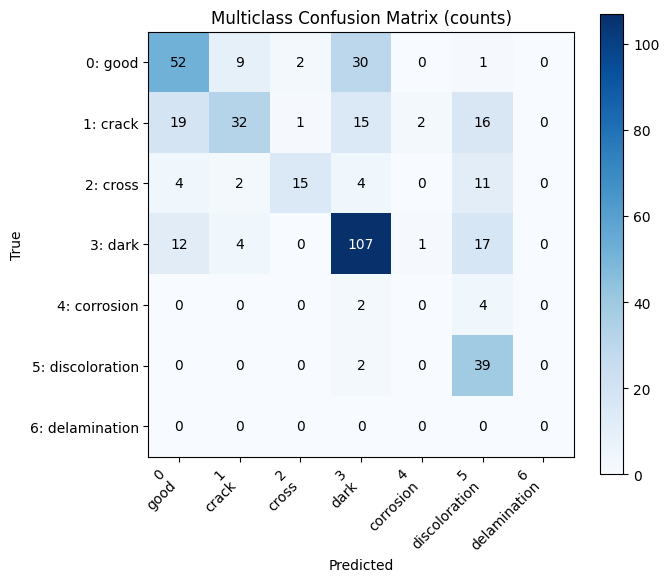

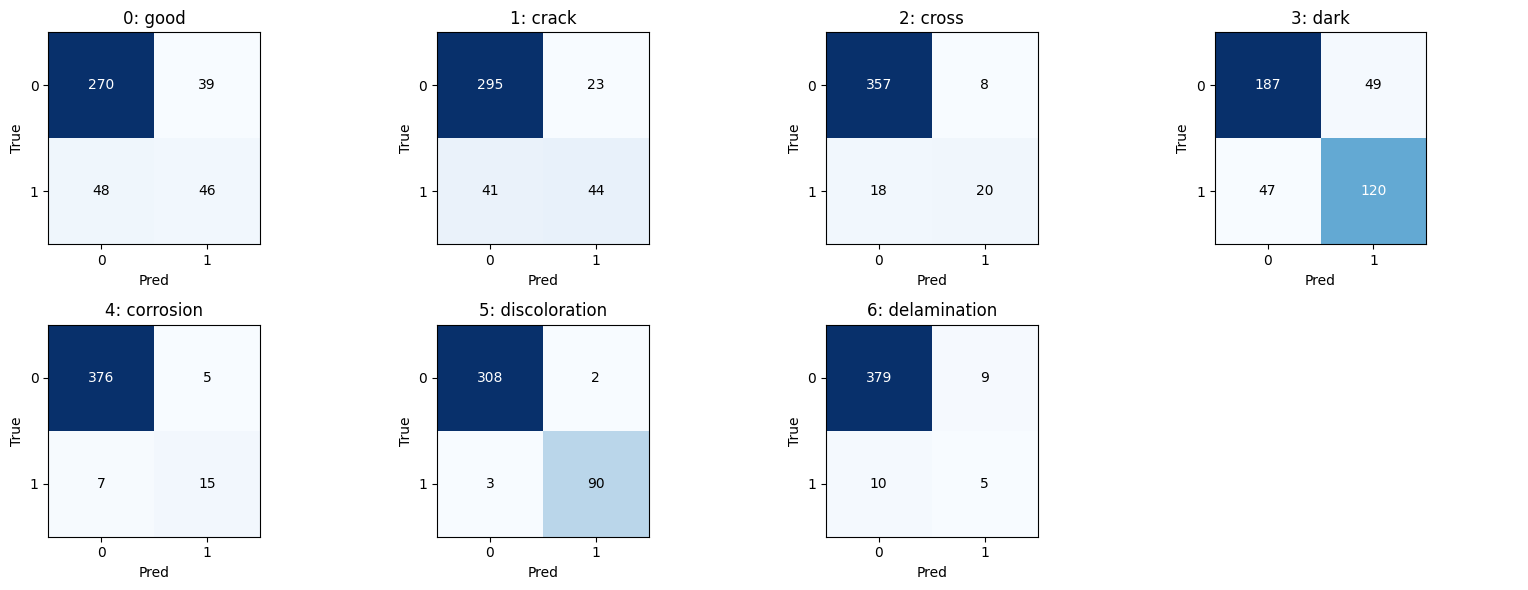

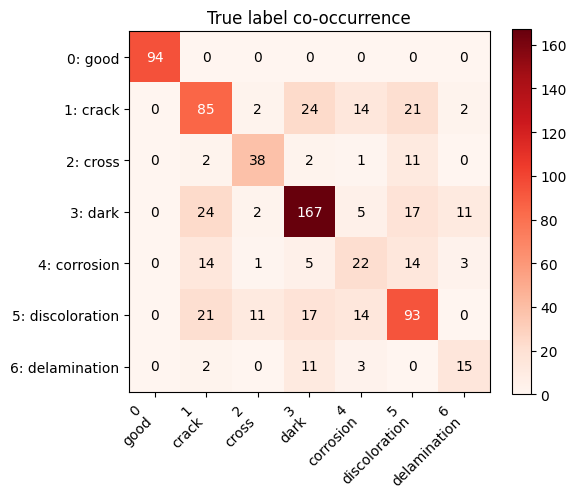

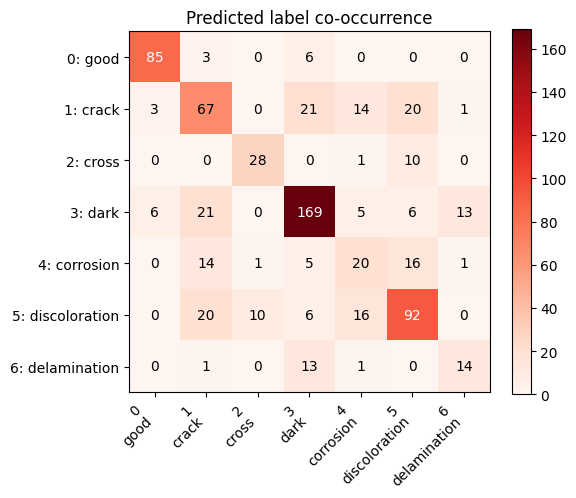

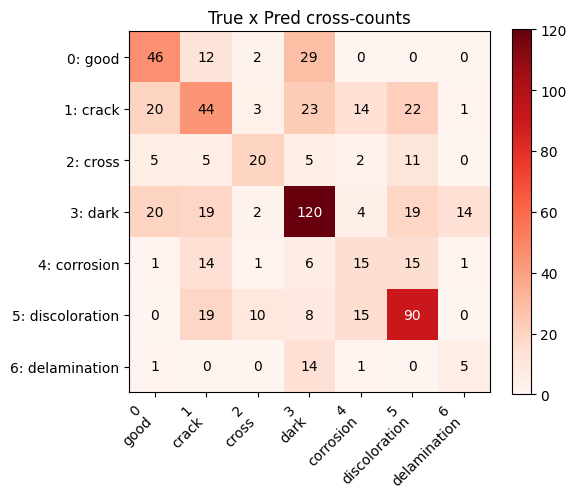

In [56]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Inputs expected from previous cells:
# true: (N,7) binary ground-truth
# probs: (N,7) predicted probabilities
# preds_bin: (N,7) binary predictions (thresholded)

class_names = ['good','crack','cross','dark','corrosion','discoloration','delamination']

# -------------------------------------------------------
# A) If your problem is actually single-label per sample:
#    use this to build a standard multiclass confusion matrix
# -------------------------------------------------------
def plot_multiclass_confusion(true_bin, probs, normalize='true'):
    # If true is one-hot, convert to single-label ints
    if true_bin.ndim==2:
        # require at least one positive; if multiple positives exist we choose argmax (warn)
        multi_pos = (true_bin.sum(axis=1) != 1).sum()
        if multi_pos:
            print(f"Warning: {multi_pos} samples are not single-label. Using argmax to convert to single-label.")
        true_single = np.argmax(true_bin, axis=1)
    else:
        true_single = true_bin.astype(int)

    # predicted single label: choose argmax of probs (or preds_bin if you prefer)
    pred_single = np.argmax(probs, axis=1)

    cm = confusion_matrix(true_single, pred_single, labels=np.arange(len(class_names)))
    # plot
    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title("Multiclass Confusion Matrix (counts)")
    fig.colorbar(im, ax=ax)
    ax.set_xticks(np.arange(len(class_names))); ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels([f"{i}\n{name}" for i,name in enumerate(class_names)], rotation=45, ha='right')
    ax.set_yticklabels([f"{i}: {name}" for i,name in enumerate(class_names)])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    # annotate
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm.max()>0 and cm[i,j] > cm.max()/2 else 'black')
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------
# B) For true multi-label data — useful confusion views
#    1) Per-class 2x2 confusion matrices (TP/FP/TN/FN)
#    2) Label co-occurrence matrices (true & predicted)
# -------------------------------------------------------
def per_class_binary_confusions(true_bin, preds_bin):
    n_classes = true_bin.shape[1]
    cms = []
    for c in range(n_classes):
        cm = confusion_matrix(true_bin[:,c].astype(int), preds_bin[:,c].astype(int), labels=[0,1])
        # cm layout: [[TN, FP],[FN, TP]]
        cms.append(cm)
    return cms

def plot_per_class_confusions(cms, class_names):
    n = len(cms)
    cols = 4
    rows = int(np.ceil(n/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    axes = axes.flatten()
    for i, cm in enumerate(cms):
        ax = axes[i]
        im = ax.imshow(cm, cmap='Blues')
        ax.set_title(f"{i}: {class_names[i]}")
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xlabel('Pred'); ax.set_ylabel('True')
        # annotate
        for r in range(2):
            for c in range(2):
                ax.text(c, r, int(cm[r,c]), ha='center', va='center', color='white' if cm.max()>0 and cm[r,c] > cm.max()/2 else 'black')
    for j in range(n, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

def label_cooccurrence(true_bin, preds_bin):
    # counts of true co-occurrence: true.T @ true -> (7,7)
    true_co = (true_bin.astype(int).T @ true_bin.astype(int))
    pred_co = (preds_bin.astype(int).T @ preds_bin.astype(int))
    cross = (true_bin.astype(int).T @ preds_bin.astype(int))  # how often true i co-occurs with predicted j
    return true_co, pred_co, cross

def plot_matrix(mat, title, labels):
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(mat, cmap='Reds')
    ax.set_title(title)
    ax.set_xticks(np.arange(len(labels))); ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels([f"{i}\n{name}" for i,name in enumerate(labels)], rotation=45, ha='right')
    ax.set_yticklabels([f"{i}: {name}" for i,name in enumerate(labels)])
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, int(mat[i,j]), ha='center', va='center', color='white' if mat.max()>0 and mat[i,j] > mat.max()/2 else 'black')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

# -------------------------
# Run appropriate functions
# -------------------------
# If your dataset is truly single-label use plot_multiclass_confusion(...)
plot_multiclass_confusion(true, probs)   # only if single-label; otherwise will warn

# For multi-label inspection:
preds_bin = (probs >= 0.5).astype(int)
cms = per_class_binary_confusions(true, preds_bin)
plot_per_class_confusions(cms, class_names)

true_co, pred_co, cross_co = label_cooccurrence(true, preds_bin)
plot_matrix(true_co, "True label co-occurrence", class_names)
plot_matrix(pred_co, "Predicted label co-occurrence", class_names)
plot_matrix(cross_co, "True x Pred cross-counts", class_names)
# ...existing code...

Class	AP	Prec	Rec	F1	Support	Thresh
0:good	0.580	0.456	0.819	0.586	94	0.14
1:crack	0.655	0.592	0.682	0.634	85	0.33
2:cross	0.614	0.533	0.632	0.578	38	0.26
3:dark	0.743	0.774	0.677	0.722	167	0.51
4:corrosion	0.722	0.708	0.773	0.739	22	0.32
5:discoloration	0.944	0.947	0.957	0.952	93	0.52
6:delamination	0.248	0.308	0.533	0.390	15	0.17

 mAP: 0.644
 macro-F1: 0.657  micro-F1: 0.692
 Hamming loss: 0.1219  Subset accuracy: 0.469


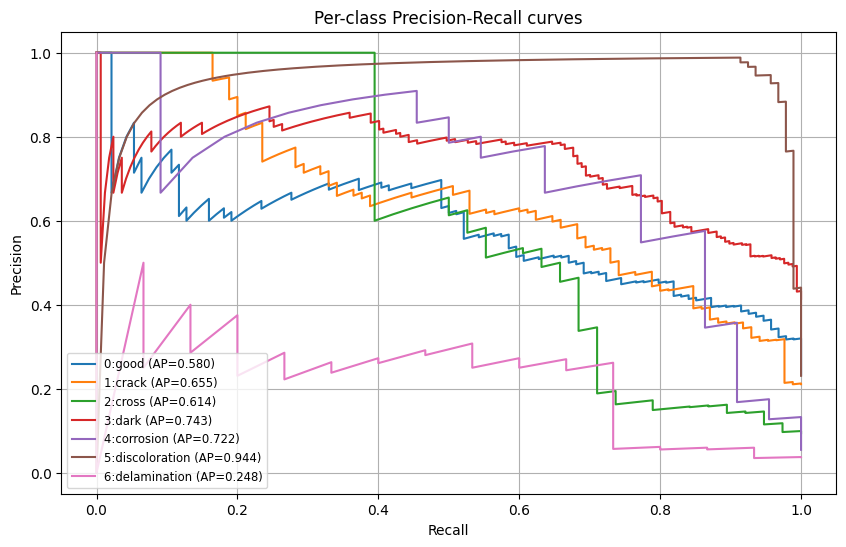

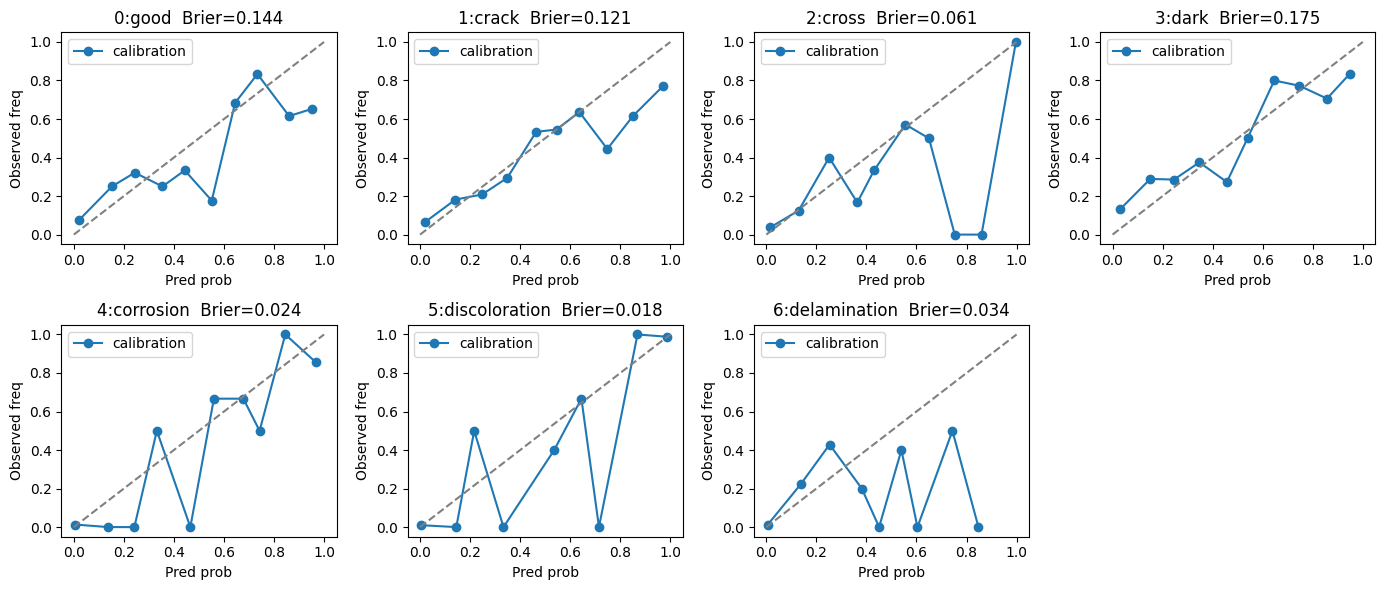

macro-F1 95% CI: [0.614, 0.700]  median: 0.656
Not all samples are single-label. Skipping multiclass confusion matrix (would discard multi-label info).


In [79]:
# ...existing code...
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, auc,
    precision_recall_fscore_support, f1_score, hamming_loss,
    jaccard_score
)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss



assert probs is not None and true is not None, "Need probs and true arrays."

n_classes = probs.shape[1]
class_names = ['good','crack','cross','dark','corrosion','discoloration','delamination'][:n_classes]

# Find per-class threshold by maximizing F1 on this data (simple method)
thresholds = np.zeros(n_classes)
for c in range(n_classes):
    p, r, thr = precision_recall_curve(true[:,c], probs[:,c])
    f1s = (2*p*r)/(p+r+1e-12)
    if f1s.size:
        best_idx = np.nanargmax(f1s)
        thresholds[c] = thr[best_idx] if best_idx < len(thr) else 0.5
    else:
        thresholds[c] = 0.5

# compute binary preds using per-class thresholds
preds_opt = (probs >= thresholds[None, :]).astype(int)
preds_fixed = (probs >= 0.5).astype(int)

# Per-class AP and mAP
aps = [average_precision_score(true[:,c], probs[:,c]) for c in range(n_classes)]
map_val = np.nanmean(aps)

# Per-class precision/recall/f1 for chosen threshold (here use optimized thresholds)
prec, rec, f1, sup = precision_recall_fscore_support(true, preds_opt, average=None, zero_division=0)

# Global metrics
macro_f1 = f1_score(true, preds_opt, average='macro', zero_division=0)
micro_f1 = f1_score(true, preds_opt, average='micro', zero_division=0)
hamming = hamming_loss(true, preds_opt)
subset_acc = np.mean((true == preds_opt).all(axis=1))

# Print summary table
print("Class\tAP\tPrec\tRec\tF1\tSupport\tThresh")
for i, name in enumerate(class_names):
    print(f"{i}:{name}\t{aps[i]:.3f}\t{prec[i]:.3f}\t{rec[i]:.3f}\t{f1[i]:.3f}\t{sup[i]}\t{thresholds[i]:.2f}")

print(f"\n mAP: {map_val:.3f}")
print(f" macro-F1: {macro_f1:.3f}  micro-F1: {micro_f1:.3f}")
print(f" Hamming loss: {hamming:.4f}  Subset accuracy: {subset_acc:.3f}")

# Plot Per-class PR curves
plt.figure(figsize=(10,6))
for c, name in enumerate(class_names):
    p, r, _ = precision_recall_curve(true[:,c], probs[:,c])
    pr_auc = auc(r, p)
    plt.plot(r, p, label=f"{c}:{name} (AP={aps[c]:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Per-class Precision-Recall curves")
plt.legend(loc='best', fontsize='small')
plt.grid(True); plt.show()

# Calibration plots + Brier per class
fig, axes = plt.subplots(int(np.ceil(n_classes/4)), 4, figsize=(14, 3*int(np.ceil(n_classes/4))))
axes = axes.flatten()
for c in range(n_classes):
    ax = axes[c]
    prob_true, prob_pred = calibration_curve(true[:,c], probs[:,c], n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label='calibration')
    ax.plot([0,1],[0,1],'--', color='gray')
    ax.set_title(f"{c}:{class_names[c]}  Brier={brier_score_loss(true[:,c], probs[:,c]):.3f}")
    ax.set_xlabel("Pred prob"); ax.set_ylabel("Observed freq")
    ax.legend()
for j in range(n_classes, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

# Bootstrap 95% CI for macro-F1 (using optimized thresholds)
import numpy as np
def bootstrap_metric(true, pred, metric_fn, n=500):
    N = true.shape[0]
    vals = []
    for _ in range(n):
        idx = np.random.randint(0, N, N)
        vals.append(metric_fn(true[idx], pred[idx]))
    return np.percentile(vals, [2.5, 50, 97.5])

ci = bootstrap_metric(true, preds_opt, lambda t,p: f1_score(t,p,average='macro', zero_division=0), n=300)
print(f"macro-F1 95% CI: [{ci[0]:.3f}, {ci[2]:.3f}]  median: {ci[1]:.3f}")

# Optional: if you want a standard multiclass confusion matrix, convert to single-label (argmax) but only if data is single-label
def plot_multiclass_confusion_if_singlelabel(true_bin, probs):
    if (true_bin.sum(axis=1) == 1).all():
        true_single = np.argmax(true_bin, axis=1)
        pred_single = np.argmax(probs, axis=1)
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(true_single, pred_single, labels=np.arange(n_classes))
        fig, ax = plt.subplots(figsize=(7,6))
        im = ax.imshow(cm, cmap='Blues')
        ax.set_xticks(np.arange(n_classes)); ax.set_yticks(np.arange(n_classes))
        ax.set_xticklabels([f"{i}\n{name}" for i,name in enumerate(class_names)], rotation=45, ha='right')
        ax.set_yticklabels([f"{i}: {name}" for i,name in enumerate(class_names)])
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j,i,cm[i,j],ha='center',va='center', color='white' if cm.max()>0 and cm[i,j]>cm.max()/2 else 'black')
        plt.colorbar(im, ax=ax); plt.tight_layout(); plt.title("Multiclass Confusion Matrix (counts)"); plt.show()
    else:
        print("Not all samples are single-label. Skipping multiclass confusion matrix (would discard multi-label info).")

plot_multiclass_confusion_if_singlelabel(true, probs)
# ...existing code...